<a href="https://colab.research.google.com/github/MukherjeeDebjani11/-MukherjeeDebjani11github.io/blob/main/Customer_Segmentation_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt
%matplotlib inline


In [ ]:
df=pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


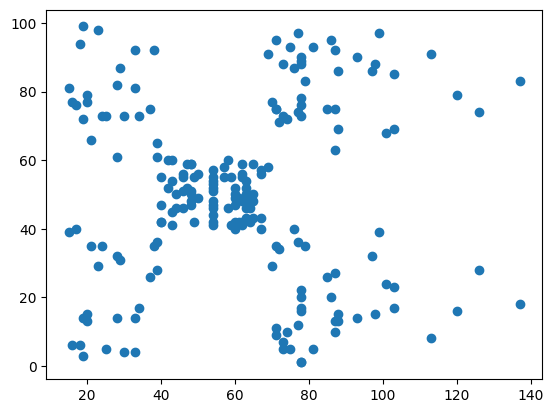

In [ ]:
plt.scatter(df['Annual Income (k$)'],df['Spending Score (1-100)'])

In [ ]:
km=KMeans(n_clusters=5)
km

KMeans(n_clusters=5)

In [ ]:
y_predicted=km.fit_predict(df[['Annual Income (k$)','Spending Score (1-100)']])
y_predicted

array([3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 1,
       3, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 2, 0, 1, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 1, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0], dtype=int32)

In [ ]:
df['cluster']=y_predicted
df.head()

NameError: name 'y_predicted' is not defined

/tmp/ipykernel_4327/32771923.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


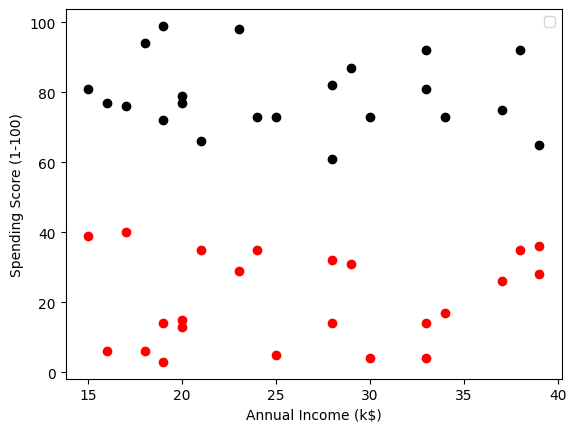

In [ ]:
df1=df[df.cluster==3]
df2=df[df.cluster==4]
plt.scatter(df1['Annual Income (k$)'],df1['Spending Score (1-100)'], color='red')
plt.scatter(df2['Annual Income (k$)'],df2['Spending Score (1-100)'], color='black')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()

In [ ]:
# Visualize all 5 clusters
df0 = df[df.cluster==0]
df1 = df[df.cluster==1]
df2 = df[df.cluster==2]
df3 = df[df.cluster==3]
df4 = df[df.cluster==4]

plt.figure(figsize=(10, 7))
plt.scatter(df0['Annual Income (k$)'], df0['Spending Score (1-100)'], color='green', label='Cluster 0')
plt.scatter(df1['Annual Income (k$)'], df1['Spending Score (1-100)'], color='red', label='Cluster 1')
plt.scatter(df2['Annual Income (k$)'], df2['Spending Score (1-100)'], color='blue', label='Cluster 2')
plt.scatter(df3['Annual Income (k$)'], df3['Spending Score (1-100)'], color='purple', label='Cluster 3')
plt.scatter(df4['Annual Income (k$)'], df4['Spending Score (1-100)'], color='orange', label='Cluster 4')

# Plot the centroids as well
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], color='black', marker='*', label='Centroid', s=250)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments based on Annual Income and Spending Score')
plt.legend()
plt.grid(True)
plt.show()
plt.plot()


AttributeError: 'DataFrame' object has no attribute 'cluster'

From the visualization, it appears that K-Means has done a reasonable job of segmenting the customers into 5 distinct groups based on their 'Annual Income' and 'Spending Score'.

*   **Cluster 0 (Green):** Low income, high spending. (Target customers for promotions)
*   **Cluster 1 (Red):** High income, low spending. (Potential to increase spending)
*   **Cluster 2 (Blue):** High income, high spending. (Valuable customers)
*   **Cluster 3 (Purple):** Low income, low spending. (Less valuable, perhaps focus on basic needs)
*   **Cluster 4 (Orange):** Mid income, mid spending. (Average customers)

The clusters seem relatively well-separated, which suggests that 5 clusters might be a good number for this dataset. The centroids (black stars) are at the centers of these groups, as expected. However, for a more quantitative evaluation, you could also look at metrics like inertia or silhouette score.

In [ ]:
k_rng=range(1,10)
sse=[]
for k in k_rng:
  km=KMeans(n_clusters=k)
  km.fit(df[['Annual Income (k$)','Spending Score (1-100)']])
  sse.append(km.inertia_)

In [ ]:
sse

[269981.28000000014,
 186362.95600651755,
 106348.37306211119,
 73679.78903948837,
 44448.45544793369,
 37455.98455516028,
 32233.422550637762,
 26676.78076960076,
 24002.542133832354]

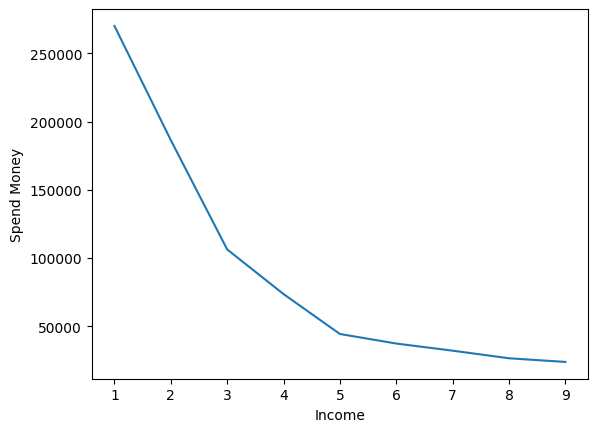

In [ ]:
plt.xlabel('Income')
plt.ylabel('Spend Money')
plt.plot(k_rng,sse)


In [ ]:
# Elbow Method Shown Clearly